In [ ]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

random.seed(42)
dtype = torch.float32
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
n_library = 100000
n_hit_candidates = 100000
n_test = 100000
min_length = 10
max_length = 30
batch_size_hits = 64
batch_size_library = 320

### Generate train and test data


In [ ]:
def generate_random_peptides(num_sequences, min_length, max_length):
    peptides = []
    for _ in range(num_sequences):
        length = random.randint(min_length, max_length)
        peptide = "".join(random.choices(amino_acids, k=length))
        peptides.append(peptide)
    return peptides


def one_hot_encode_sequences(sequences, max_length):
    aa_to_idx = {aa: idx for idx, aa in enumerate(amino_acids)}
    one_hot = torch.zeros((len(sequences), max_length, 20), dtype=dtype)
    for i, seq in enumerate(sequences):
        for j, aa in enumerate(seq):
            if aa in aa_to_idx:
                one_hot[i, j, aa_to_idx[aa]] = 1.0
    return one_hot


def true_f(sequences):
    patterns = ["ACD", "KLM", "QRS", "FGH", "VWY"]
    return torch.tensor(
        [1 if any(p in s for p in patterns) else 0 for s in sequences], dtype=dtype
    )


# Sample training (library and hit candidates) and test sequences.
x_library = generate_random_peptides(n_library, min_length, max_length)
x_hit_candidates = generate_random_peptides(n_hit_candidates, min_length, max_length)
x_test = generate_random_peptides(n_test, min_length, max_length)

# Simulate true labels with a pattern-based function.
y_hit_candidates = true_f(x_hit_candidates)
y_test = true_f(x_test)

# Select actual hits.
is_hit = y_hit_candidates == 1
hit_rate = is_hit.mean(dtype=dtype).item()
x_hits = [x_hit_candidates[i] for i in range(len(x_hit_candidates)) if is_hit[i]]

# Make one-hot encodings.
x_oh_library = one_hot_encode_sequences(x_library, max_length)
x_oh_hits = one_hot_encode_sequences(x_hits, max_length)
x_oh_test = one_hot_encode_sequences(x_test, max_length)

x_oh_candidates = one_hot_encode_sequences(x_hit_candidates, max_length)

In [3]:
class LeaVSLoss(nn.Module):
    def __init__(self, hit_rate: float):
        super().__init__()
        self._hit_rate = hit_rate

    def forward(self, p_theta_hits: torch.Tensor, p_theta_library: torch.Tensor):
        # Compute the LeaVS loss.
        objective_hits = torch.mean(torch.log(p_theta_hits))
        objective_library = torch.log(torch.mean(1 - p_theta_library))
        return (
            -self._hit_rate * objective_hits - (1 - self._hit_rate) * objective_library
        )

### Train a simple CNN using the LeaVS loss

In [ ]:
loader_hits = DataLoader(
    x_oh_hits, batch_size=batch_size_hits, shuffle=True, drop_last=True
)
loader_library = DataLoader(
    x_oh_library, batch_size=batch_size_library, shuffle=True, drop_last=True
)


# Define a simple CNN model
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(len(amino_acids), 30, kernel_size=3, padding=0)
        self.relu = nn.ReLU()
        self.linear = nn.Linear(30, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = torch.max(x, dim=-1).values
        x = x.max(dim=-1).values.unsqueeze(1)
        x = self.sigmoid(x)
        return x.squeeze(-1)


model = CNNModel()
criterion = LeaVSLoss(hit_rate)
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=0.00005)

# Training loop
n_epochs = 500
pbar = tqdm(range(n_epochs))
for epoch in pbar:

    model.train()
    running_loss = 0.0
    n_batches = 0
    library_iterator = iter(loader_library)

    for x_batch_hits in loader_hits:
        try:
            x_batch_library = next(library_iterator)
        except StopIteration:
            library_iterator = iter(loader_library)
            data2 = next(library_iterator)

        optimizer.zero_grad()

        # Compute LeaVS loss for batch.
        y_batch_hits = model(x_batch_hits)
        y_batch_library = model(x_batch_library)
        loss = criterion(y_batch_hits, y_batch_library)

        # Backpropagate and update weights.
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    epoch_loss = running_loss / n_batches
    if epoch % 10 == 0:
        pbar.set_description(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

### Evaluate model

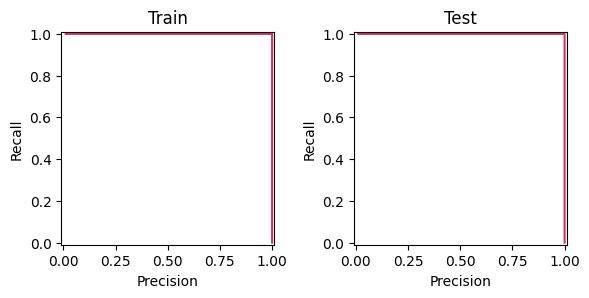

In [ ]:
y_train = y_hit_candidates
y_train_pred = model(x_oh_candidates).detach().numpy()

y_test = y_test
y_test_pred = model(x_oh_test).detach().numpy()

precisions_train, recalls_train, thresholds_train = precision_recall_curve(
    y_true=y_train, y_score=y_train_pred
)
precisions_test, recalls_test, thresholds_test = precision_recall_curve(
    y_true=y_test, y_score=y_test_pred
)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))

color = "#CC3363"
ax1.plot(
    precisions_train,
    recalls_train,
    color=color,
)
ax1.set_xlim((-0.01, 1.01))
ax1.set_ylim((-0.01, 1.01))
ax1.set_xlabel("Precision")
ax1.set_ylabel("Recall")
ax1.set_aspect("equal")
ax1.set_title("Train")

ax2.plot(
    precisions_test,
    recalls_test,
    color=color,
)
ax2.set_xlim((-0.01, 1.01))
ax2.set_ylim((-0.01, 1.01))
ax2.set_xlabel("Precision")
ax2.set_ylabel("Recall")
ax2.set_aspect("equal")
ax2.set_title("Test")


fig.tight_layout()
fig.show()

<Axes: xlabel='True', ylabel='Predicted'>

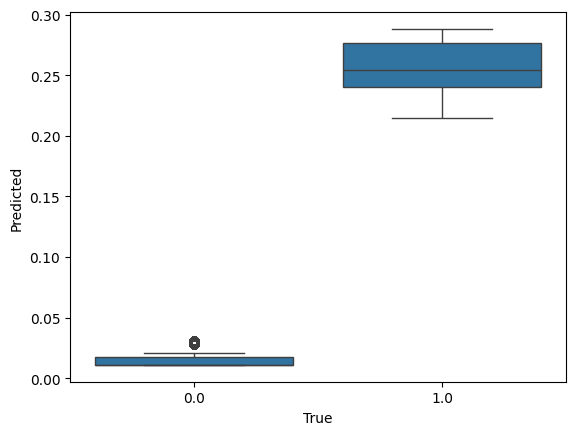

In [ ]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))

pred_df = pd.DataFrame({"True": y_train, "Predicted": y_train_pred})
sns.boxplot(pred_df, x="True", y="Predicted", ax=ax0)

pred_df = pd.DataFrame({"True": y_test, "Predicted": y_test_pred})
sns.boxplot(pred_df, x="True", y="Predicted", ax=ax1)

fig.tight_layout()